# Predict Future Stock Prices (Short-Term)

## Problem Statement:
Stock prices keep changing every day, and it’s not easy to predict what will happen next. Just looking at past data doesn’t clearly tell us the future price. So, the problem is how to use historical stock data to make a simple prediction of the next day’s closing price.

## Goal/Objectives:
The goal is to learn how to use past stock data to predict future prices. This includes collecting data using yfinance, training a model like Linear Regression or Random Forest, and comparing predicted prices with actual prices using graphs.

In [ ]:
# import yfinance (Yahoo Finanace) python library
import yfinance as yf
import pandas as pd

A ticker of a stock is  uniques grouping of letters that identifies a specific company. It carries information on a stock: its name, it's worth, how many shares are available at the current price, and whetere the price has risen or fallen during the day.

In [ ]:
# download Tesla stock market data using its Ticker "TSLA"
tesla = yf.Ticker("TSLA")

We will choose the last 1 year data as it is more relevant to what is happening in the market right now.

In [ ]:
# pull the last 1 year data
tesla_df = tesla.history(period="1y")

In [ ]:
# pulls the first 5 rows of a data frame
tesla_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-04-28 00:00:00-04:00,288.980011,294.859985,272.420013,285.880005,151731800,0.0,0.0
2025-04-29 00:00:00-04:00,285.500000,293.320007,279.470001,292.029999,108906600,0.0,0.0
2025-04-30 00:00:00-04:00,279.899994,284.450012,270.779999,282.160004,128961100,0.0,0.0
2025-05-01 00:00:00-04:00,280.010010,290.869995,279.809998,280.519989,99659000,0.0,0.0
2025-05-02 00:00:00-04:00,284.899994,294.779999,279.809998,287.209991,114454700,0.0,0.0


In [ ]:
# how many rows and columns the dataset contain? - returns a tuple of rows and columns
tesla_df.shape

(251, 7)

In [ ]:
# check the column names
tesla_df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [ ]:
# Are there any NaN values present?
tesla_df.isna().values.any()

np.False_

In [ ]:
# How many NaN values are there present?
tesla_df.isna().sum()

,0
Open,0
High,0
Low,0
Close,0
Volume,0
Dividends,0
Stock Splits,0


In [ ]:
tesla_df.isna().values

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [ ]:
# Are there any duplicate rows present?
tesla_df.duplicated().values.any()

np.False_

In [ ]:
# How many duplicated rows are there?
tesla_df.duplicated().sum()

np.int64(0)

In [ ]:
# information about the dataframe, also the data types
tesla_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-04-28 00:00:00-04:00 to 2026-04-27 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          251 non-null    float64
 1   High          251 non-null    float64
 2   Low           251 non-null    float64
 3   Close         251 non-null    float64
 4   Volume        251 non-null    int64  
 5   Dividends     251 non-null    float64
 6   Stock Splits  251 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 15.7 KB


In [ ]:
# pulls random rows from the data frame
tesla_df.sample(5)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-04-09 00:00:00-04:00,343.149994,348.880005,337.250000,345.619995,62164000,0.0,0.0
2026-01-07 00:00:00-05:00,435.899994,438.369995,431.290009,431.410004,59828800,0.0,0.0
2026-01-15 00:00:00-05:00,441.130005,445.359985,437.649994,438.570007,49465800,0.0,0.0
2026-03-30 00:00:00-04:00,365.859985,367.290009,352.140015,355.279999,67954400,0.0,0.0
2026-02-17 00:00:00-05:00,412.359985,413.720001,400.510010,410.630005,59678800,0.0,0.0


In [ ]:
# shows a detailed statistics
tesla_df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,251.000000,251.000000,251.000000,251.000000,2.510000e+02,251.0,251.0
mean,384.588924,391.633505,377.266454,384.495498,8.396165e+07,0.0,0.0
std,55.463387,55.758312,54.525664,55.073234,2.947726e+07,0.0,0.0
min,273.109985,277.730011,270.779999,275.350006,3.625290e+07,0.0,0.0
25%,335.480011,341.774994,328.590012,334.354996,6.236510e+07,0.0,0.0
50%,395.690002,402.100006,387.529999,395.010010,7.769760e+07,0.0,0.0
75%,434.815002,440.490005,425.260010,432.209991,9.741210e+07,0.0,0.0
max,489.880005,498.829987,485.329987,489.880005,2.874998e+08,0.0,0.0


In [ ]:
# libraries for plotting graphs
import matplotlib.pyplot as plt
import seaborn as sns


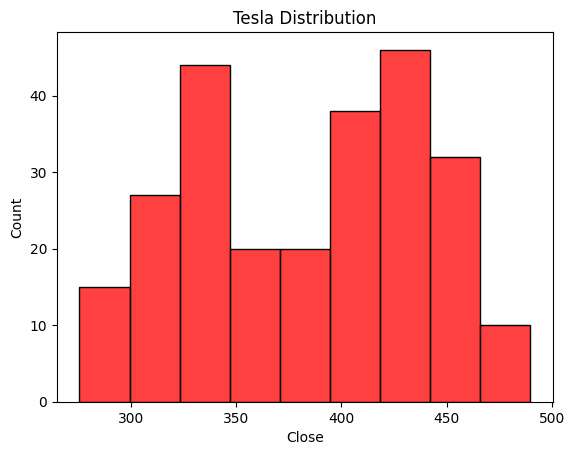

In [ ]:
# shows the distribution of data in the data frame
sns.histplot(x=tesla_df.Close, color='red')
plt.title("Tesla Distribution")
plt.show()

In [ ]:
# we choose the label y (prediction target) as Closing price
y = tesla_df.Close

In [ ]:
# pulls the columns of the data frame, we need to select for features
tesla_df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits'], dtype='object')

In [ ]:
# choosing features - columns used for the prediction
tesla_features = ['Open', 'High', 'Low', 'Volume']
X = tesla_df[tesla_features]

In [ ]:
# checks the number of rows and columns
X.shape

(252, 4)

In [ ]:
# checking the first two rows of the selected data frame.
# here we can see the index values are the dates
X.head(2)

,Open,High,Low,Volume
Date,,,,
2025-04-28 00:00:00-04:00,288.980011,294.859985,272.420013,151731800
2025-04-29 00:00:00-04:00,285.500000,293.320007,279.470001,108906600


In [ ]:
# the index are the dates, so we need to drop it
X = X.reset_index(drop=True)
X.head()

,Open,High,Low,Volume
0,288.980011,294.859985,272.420013,151731800
1,285.500000,293.320007,279.470001,108906600
2,279.899994,284.450012,270.779999,128961100
3,280.010010,290.869995,279.809998,99659000
4,284.899994,294.779999,279.809998,114454700


<Axes: xlabel='Volume'>

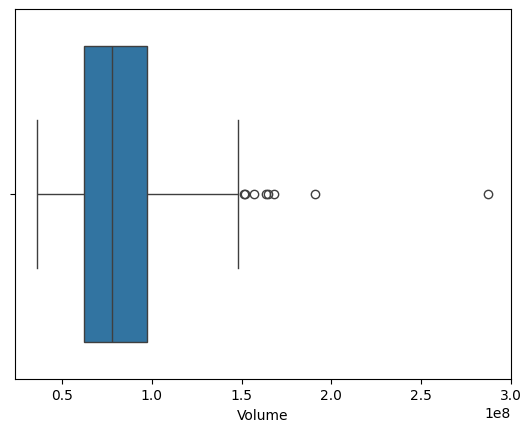

In [ ]:
# we can also check outliers using box and whisker plot.
import seaborn as sns
sns.boxplot(data=X, x=X.Volume)

We will use Scikit-learn library to create machine learning models

The steps to building and using a model are:
* **Define**: What type of model will it be?
* **Fit**: Capture patterns from provided data.
* **Predict**: Predict future data.
* **Evaluate**: Determine how accurate the model's predictions are.

## Linear Regression Model

In [1]:
# import Linear Regression Model from scikit-learn
from sklearn.linear_model import LinearRegression
# for splitting the data into training set and validation set
from sklearn.model_selection import train_test_split

In [ ]:
# we want to select data from the dataset randomly, so we defined the random state
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)
# set the model to be used - i.e. Linear Regression
stock_model = LinearRegression()
# training the model on the training data
stock_model.fit(train_X, train_y)

LinearRegression()

In [ ]:
# testing the model on the validation data
predictions = stock_model.predict(val_X)
print(predictions)

[306.90786177 379.16470621 355.85971968 482.36332119 349.84566881
 367.45425997 327.74236858 372.42025782 436.93447698 288.99797072
 403.23618424 432.24337022 431.15709414 442.40324346 462.12859304
 333.3131875  433.13844676 311.40680501 284.0387159  335.62554004
 382.78607213 328.48086266 391.24817631 448.96644226 436.82348677
 427.50664495 378.3645074  363.34229439 351.75100671 392.04616291
 385.24588546 300.81059012 326.18752418 418.97190826 478.34317288
 361.7041518  343.77850761 326.10887567 343.97541799 343.05877448
 411.38553285 338.66344883 351.7965245  427.68734456 328.89321915
 424.2131358  318.05997399 331.73376462 301.66168598 280.48539756
 376.00850853 344.45208292 439.29959339 420.85167494 451.21819443
 425.49251557 432.54955173 298.65879443 349.06431684 453.48695462
 441.94882194 432.25731228 439.77034477]


In [ ]:
y = y.reset_index(drop=True)


In [ ]:
# to see the actual values and the predicted values, we used a for loop.
for i in range(10):
    print(f"The predicted price is {predictions[i].round(2)}")
    print(f"The actual price is {val_y.iloc[i].round(2)}")

The predicted price is 306.91
The actual price is 309.26
The predicted price is 379.16
The actual price is 376.16
The predicted price is 355.86
The actual price is 355.28
The predicted price is 482.36
The actual price is 489.88
The predicted price is 349.85
The actual price is 346.4
The predicted price is 367.45
The actual price is 367.96
The predicted price is 327.74
The actual price is 332.11
The predicted price is 372.42
The actual price is 378.67
The predicted price is 436.93
The actual price is 439.2
The predicted price is 289.0
The actual price is 287.21


## Random Forest Regression Model

The Random Forest Regression Model is a **supervised machine learning ensemble** method, that combines the predictions of multiple decision trees to produce a single, more accurate predictions.

In [ ]:
# importing Random Forest Regressor from scikit-learn
from sklearn.ensemble import RandomForestRegressor
# n_estimators tells the number of trees the model will build before averaging predictions
tesla_stock_model_rf = RandomForestRegressor(n_estimators=90, random_state=1)
# training the model on the data
tesla_stock_model_rf.fit(train_X, train_y)

RandomForestRegressor(random_state=1)

In [ ]:
# testing the model predictions
rf_predictions = tesla_stock_model_rf.predict(val_X)

In [ ]:
# to see the actual values and the predicted values, we used a for loop.
for i in range(10):
    print(f"The predicted price is {rf_predictions[i].round(2)}")
    print(f"The actual price is {val_y.iloc[i].round(2)}")

The predicted price is 309.65
The actual price is 309.26
The predicted price is 378.46
The actual price is 376.16
The predicted price is 357.86
The actual price is 355.28
The predicted price is 469.92
The actual price is 489.88
The predicted price is 349.35
The actual price is 346.4
The predicted price is 375.37
The actual price is 367.96
The predicted price is 329.19
The actual price is 332.11
The predicted price is 376.71
The actual price is 378.67
The predicted price is 439.7
The actual price is 439.2
The predicted price is 286.65
The actual price is 287.21


In [ ]:
# to evaluate the model predictions we use MAE - Mean Absolute Error
from sklearn.metrics import mean_absolute_error
mean_absolute_error(val_y, rf_predictions)

4.563735002790178

## Plotting Data via Seaborn and Matplot

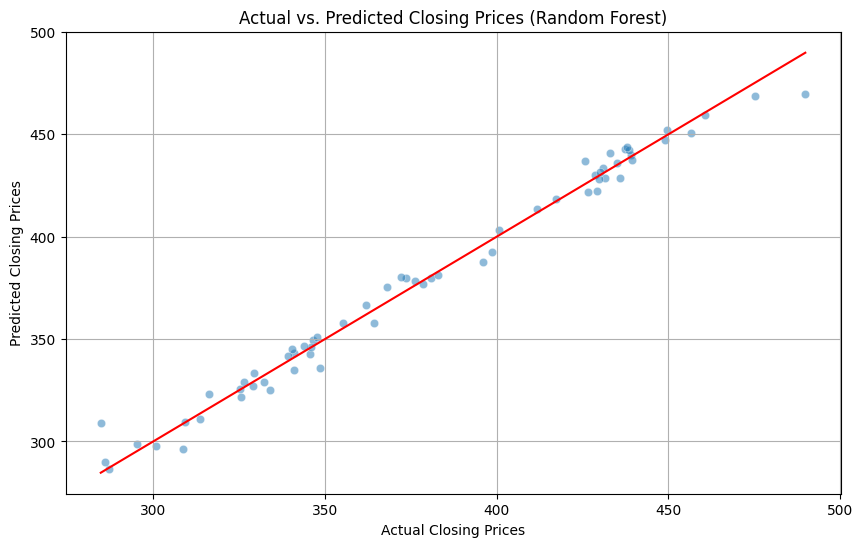

In [ ]:
# Plotting the Actual and Predicted prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=val_y, y=rf_predictions, alpha=0.5) # Using seaborn for scatterplot
plt.plot([min(val_y), max(val_y)], [min(val_y), max(val_y)], 'r-') # Diagonal line for perfect prediction
plt.xlabel('Actual Closing Prices')
plt.ylabel('Predicted Closing Prices')
plt.title('Actual vs. Predicted Closing Prices (Random Forest)')
plt.grid(True)
plt.show()

# Apple Stock data

In [ ]:
# downloading Apple Inc. Stock Data from Yahoo Finance
apple = yf.Ticker("AAPL")
apple_df = apple.history(period="1y")

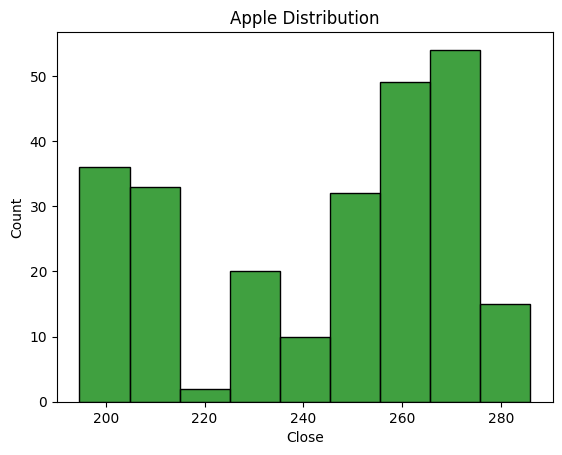

In [ ]:
# plotting the data to see the distribution
sns.histplot(x=apple_df.Close, color='green')
plt.title("Apple Distribution")
plt.show()


In [ ]:
# we choose the label y (prediction target) as Closing price
y = apple_df.Close

In [ ]:
# choosing features - columns used for the prediction
apple_features = ['Open', 'High', 'Low', 'Volume']
X = apple_df[apple_features]

In [ ]:
# the index are the dates, we need to drop it
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

In [ ]:
# shows the last 5 rows of the data frame
X.tail()

,Open,High,Low,Volume
246,267.820007,273.739990,266.869995,43249200
247,275.049988,275.769989,271.649994,33399600
248,272.760010,273.059998,269.649994,38157100
249,266.089996,268.359985,265.070007,41466800
250,272.334991,273.220001,268.660004,32820055


In [ ]:
# importing Random Forest Regressor from scikit-learn
from sklearn.ensemble import RandomForestRegressor

# for splitting the data into training set and validation set
from sklearn.model_selection import train_test_split
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

# n_estimators tells the number of trees the model will build before averaging predictions
apple_model = RandomForestRegressor(n_estimators=90)
# training the model on the data
apple_model.fit(train_X, train_y)

RandomForestRegressor()

In [ ]:
# testing the model predictions
forest_predictions = apple_model.predict(val_X)


In [ ]:
# to see the actual values and the predicted values, we used a for loop.
for i in range(10):
    print(f"The predicted price is {forest_predictions[i].round(2)}")
    print(f"The actual price is {val_y.iloc[i].round(2)}")


The predicted price is 201.74
The actual price is 202.3
The predicted price is 270.83
The actual price is 270.71
The predicted price is 249.95
The actual price is 246.63
The predicted price is 273.32
The actual price is 271.59
The predicted price is 237.38
The actual price is 233.9
The predicted price is 250.17
The actual price is 247.99
The predicted price is 213.34
The actual price is 213.5
The predicted price is 259.67
The actual price is 258.86
The predicted price is 259.99
The actual price is 257.97
The predicted price is 199.74
The actual price is 198.03


In [ ]:
# to evaluate the model predictions we use MAE - Mean Absolute Error
from sklearn.metrics import mean_absolute_error
mean_absolute_error(val_y, forest_predictions)

1.2471899825807593

## Plotting Data via Seaborn

Text(0.5, 1.0, 'Actual vs. Predicted Closing Prices (Random Forest)')

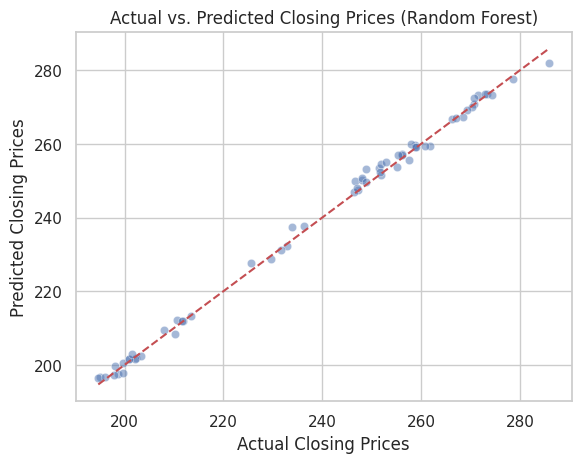

In [ ]:
# Plotting the Actual and Predicted prices
sns.set_theme(style="whitegrid")
ax = sns.scatterplot(x=val_y, y=forest_predictions, alpha=0.5)
ax.plot([min(val_y), max(val_y)], [min(val_y), max(val_y)], 'r--')
ax.set_title('Actual vs. Predicted Closing Prices (Random Forest)')
ax.set_xlabel('Actual Closing Prices')
ax.set_ylabel('Predicted Closing Prices')
